# Assignment #2 - Recursive Feature Elimination with Linear Regression
Bryce Emery

This code uses the provided RFE example code as a referenece source.

In [16]:
# Initialization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# ref: https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.model_selection import cross_val_score, train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

np.random.seed(42)
# ref: https://www.geeksforgeeks.org/python/formatting-integer-column-of-dataframe-in-pandas/
# I don't want scientific notation for the describe functions
pd.options.display.float_format = '{:.8f}'.format


## Task 1 - Data set Exploration

In [17]:
# load dataset
diabetes_data = load_diabetes()

X = pd.DataFrame(data=diabetes_data.data,
                 columns=diabetes_data.feature_names)
y = diabetes_data.target

# standardize features
#scalar = StandardScaler()
#X_scaled = scalar.fit_transform(X)


In [18]:
print(X.head)
print(f"Target: {y}")

<bound method NDFrame.head of             age         sex         bmi          bp          s1          s2  \
0    0.03807591  0.05068012  0.06169621  0.02187239 -0.04422350 -0.03482076   
1   -0.00188202 -0.04464164 -0.05147406 -0.02632753 -0.00844872 -0.01916334   
2    0.08529891  0.05068012  0.04445121 -0.00567042 -0.04559945 -0.03419447   
3   -0.08906294 -0.04464164 -0.01159501 -0.03665608  0.01219057  0.02499059   
4    0.00538306 -0.04464164 -0.03638469  0.02187239  0.00393485  0.01559614   
..          ...         ...         ...         ...         ...         ...   
437  0.04170844  0.05068012  0.01966154  0.05974375 -0.00569682 -0.00256647   
438 -0.00551455  0.05068012 -0.01590626 -0.06764174  0.04934130  0.07916528   
439  0.04170844  0.05068012 -0.01590626  0.01729339 -0.03734373 -0.01383982   
440 -0.04547248 -0.04464164  0.03906215  0.00121528  0.01631843  0.01528299   
441 -0.04547248 -0.04464164 -0.07303030 -0.08141314  0.08374012  0.02780893   

             s3      

All features are normalized, with a mean of 0.0 and standard deviation of 0.0476.

### Per Feature Descriptions:

#### age

In [19]:
print(f"Median: {X['age'].median()}")
X[['age']].describe()

Median: 0.005383060374248237


,age
count,442.00000000
mean,-0.00000000
std,0.04761905
min,-0.10722563
25%,-0.03729927
50%,0.00538306
75%,0.03807591
max,0.11072668


The age variable has a median of 0.00538, with minimum of -0.1072, and a maxmimum of 0.1107.

#### sex

In [20]:
print(f"Median: {X['sex'].median()}")
X[['sex']].describe()

Median: -0.044641636506989144


,sex
count,442.00000000
mean,0.00000000
std,0.04761905
min,-0.04464164
25%,-0.04464164
50%,-0.04464164
75%,0.05068012
max,0.05068012


The age variable has a median of -0.0446, with minimum of -0.0446, and a maxmimum of 0.0507.

Noticeably the data seems to exist in two states, at -0.0446 and 0.0507. This seems expectable as, this data was likely stored as a binary factors ('Male' or 'Female') before being normalized.

#### bmi

In [21]:
print(f"Median: {X['bmi'].median()}")
X[['bmi']].describe()

Median: -0.007283766209687899


,bmi
count,442.00000000
mean,-0.00000000
std,0.04761905
min,-0.09027530
25%,-0.03422907
50%,-0.00728377
75%,0.03124802
max,0.17055523


The bmi (body mass index) variable has a median of -0.00728, with minimum of -0.0903, and a maxmimum of 0.1706.

#### bp

In [22]:
print(f"Median: {X['bp'].median()}")
X[['bp']].describe()

Median: -0.00567042229275739


,bp
count,442.00000000
mean,-0.00000000
std,0.04761905
min,-0.11239880
25%,-0.03665608
50%,-0.00567042
75%,0.03564379
max,0.13204362


The bp (blood pressure) variable has a median of -0.00567, with minimum of -0.1124, and a maxmimum of 0.1320.

#### s1-s2 - quantitative blood sample derived variables

In [23]:
print(f"Median: {X['s1'].median()}")
print(X[['s1']].describe())
print(f"Median: {X['s2'].median()}")
print(X[['s2']].describe())
print(f"Median: {X['s3'].median()}")
print(X[['s3']].describe())
print(f"Median: {X['s4'].median()}")
print(X[['s4']].describe())
print(f"Median: {X['s5'].median()}")
print(X[['s5']].describe())
print(f"Median: {X['s6'].median()}")
print(X[['s6']].describe())

Median: -0.004320865536613489
                s1
count 442.00000000
mean   -0.00000000
std     0.04761905
min    -0.12678067
25%    -0.03424784
50%    -0.00432087
75%     0.02835801
max     0.15391371
Median: -0.0038190651205350003
                s2
count 442.00000000
mean    0.00000000
std     0.04761905
min    -0.11561307
25%    -0.03035840
50%    -0.00381907
75%     0.02984439
max     0.19878799
Median: -0.006584467611155497
                s3
count 442.00000000
mean   -0.00000000
std     0.04761905
min    -0.10230705
25%    -0.03511716
50%    -0.00658447
75%     0.02931150
max     0.18117906
Median: -0.002592261998183278
                s4
count 442.00000000
mean   -0.00000000
std     0.04761905
min    -0.07639450
25%    -0.03949338
50%    -0.00259226
75%     0.03430886
max     0.18523444
Median: -0.0019471710869220743
                s5
count 442.00000000
mean    0.00000000
std     0.04761905
min    -0.12609712
25%    -0.03324559
50%    -0.00194717
75%     0.03243232
max     0.13

The s1 variable has a median of -0.0043, with minimum of -0.1238, and a maxmimum of 0.1539.

The s2 variable has a median of -0.0038, with minimum of -0.1156, and a maxmimum of 0.1988.

The s3 variable has a median of -0.0066, with minimum of -0.1023, and a maxmimum of 0.1812.

The s4 variable has a median of -0.0026, with minimum of -0.0764, and a maxmimum of 0.1852.

The s5 variable has a median of -0.0019, with minimum of -0.1261, and a maxmimum of 0.1336.

The s6 variable has a median of -0.0011, with minimum of -0.1378, and a maxmimum of 0.1356.

### Training Testing Split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Task 2 - Linear Regression Model

In [25]:
# Initialize Lenear Regression Model
base_model = LinearRegression()
base_model.fit(X_train, y_train)
base_pred = base_model.predict(X_test)

base_r2 = r2_score(y_test, base_pred)
print(f"Base Model R²: {base_r2}")

Base Model R²: 0.4526027629719195


## Task 3 - Implement Recursive Feature Elimination (RFE)

In [26]:

# Define recursive Feature Elimination
def perform_rfe_iteration(n_features_to_select, remaining_features=0):    

    #
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
#    initial_features = 
    model=LinearRegression()
    rfe = RFE(estimator=model, n_features_to_select=n_features_to_select)
    rfe.fit(X_train_scaled, y_train)

    
    # Get selected features
    selected_features = X.columns[rfe.support_]
    eliminated_features= X.columns[~rfe.support_]

    
    # Fit linear regression on selected features
    X_train_selected = X_train_scaled[:, rfe.support_]
    X_test_selected = X_test_scaled[:, rfe.support_]
    
    selected_model = LinearRegression()
    selected_model.fit(X_train_selected, y_train)
    selected_pred = selected_model.predict(X_test_selected)
    
    selected_r2 = r2_score(y_test, selected_pred)

    return selected_r2, selected_features, selected_model.coef_
    

def visualize_rfe_iterations(max_num_features=0, output=True, r_sqr_thresh=0.01):

    coef_values = []
    rsqr_scores = []
    high_rsqr = 0
    num_features = []
    rank_history = []
    optimal_features_names = []
    
    optimal_features_num = len(X_train.columns) if max_num_features == 0 else max_num_features

    # Standardize features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    lr = LinearRegression()
    lr.fit(X_train, y_train)

    # Initial feature coeeficients
    if (output):
        print("Initial Feature Coeffecients")
        for feature, coef in zip(diabetes_data.feature_names, lr.coef_):
            print(f"{feature}: {coef:.4f}")

    for i in range(optimal_features_num, 0, -1):
        
        rsqr_score, sel_feats, sel_coefs = perform_rfe_iteration(i);
        if (output):
            print(f'--- RFE with {i} Features ---')
            
            print(f'Eliminated Features:')
            for feat in X.columns:
                if feat not in sel_feats:
                    print(feat)
            print(f'\nSelected Features and Coefficients:')
            for feat, coef in zip(sel_feats, sel_coefs):
                print(f'{feat}: {coef:.4f}')
            print(f'\nR-Squared: {rsqr_score:.4f}\n')
            
        rsqr_scores.append(rsqr_score)
        rank_history.append(sel_feats)
        coef_values.append(sel_coefs)
        num_features.append(i)
        if (rsqr_score > r_sqr_thresh and rsqr_score > high_rsqr):
            high_rsqr=rsqr_score
            optimal_features_names = sel_feats
            optimal_features_num = i

    # Plot full model
    if (output):
        plt.figure(figsize=(12,6))
        plt.plot(num_features, rsqr_scores, marker='o', label='R^2')
        plt.axvline(optimal_features_num, color='red', linestyle='--', label=f'Optimal Features ({optimal_features_num})')
        plt.title("R^2 vs Number of Selected Features")
        plt.xlabel("Number of Features")
        plt.ylabel("R^2")
        plt.legend()
        plt.grid()
        plt.show()
    return rsqr_scores, rank_history, coef_values, num_features


#perform_rfe_iteration(1)

Initial Feature Coeffecients
age: 37.9040
sex: -241.9644
bmi: 542.4288
bp: 347.7038
s1: -931.4888
s2: 518.0623
s3: 163.4200
s4: 275.3179
s5: 736.1989
s6: 48.6707
--- RFE with 10 Features ---
Eliminated Features:

Selected Features and Coefficients:
age: 1.7538
sex: -11.5118
bmi: 25.6071
bp: 16.8289
s1: -44.4489
s2: 24.6410
s3: 7.6770
s4: 13.1388
s5: 35.1612
s6: 2.3514

R-Squared: 0.4526

--- RFE with 9 Features ---
Eliminated Features:
age

Selected Features and Coefficients:
sex: -11.2590
bmi: 25.6246
bp: 17.1438
s1: -44.6808
s2: 25.1515
s3: 7.8828
s4: 12.9039
s5: 35.5552
s6: 2.5775

R-Squared: 0.4587

--- RFE with 8 Features ---
Eliminated Features:
age
s6

Selected Features and Coefficients:
sex: -11.1212
bmi: 25.9997
bp: 17.6075
s1: -45.2283
s2: 25.7598
s3: 8.0918
s4: 13.2544
s5: 36.3897

R-Squared: 0.4559

--- RFE with 7 Features ---
Eliminated Features:
age
s3
s6

Selected Features and Coefficients:
sex: -11.1978
bmi: 26.0527
bp: 17.5380
s1: -31.5246
s2: 16.3309
s4: 8.8353
s5: 31

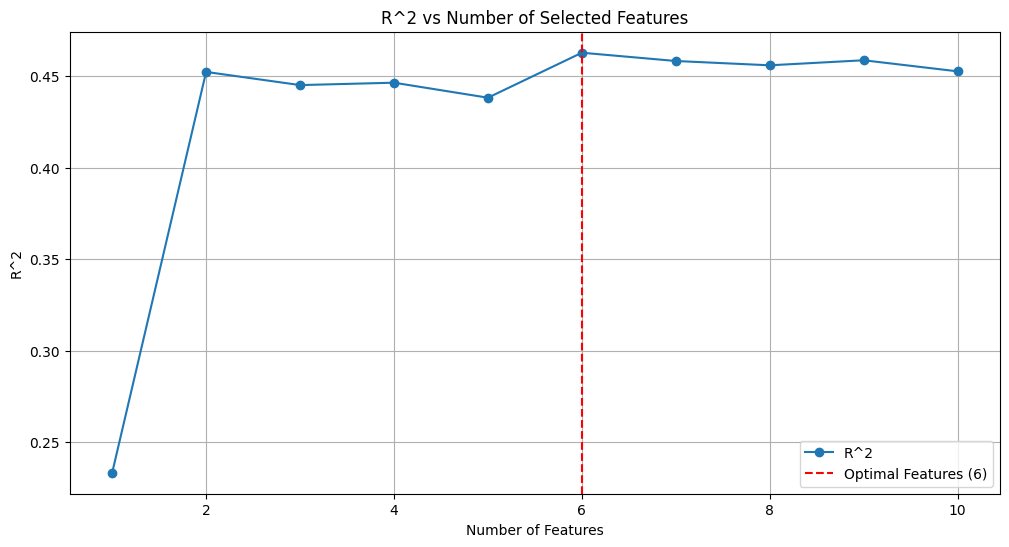

([0.45260276297191926,
  0.4586588697581955,
  0.4559010325046122,
  0.45825530847242857,
  0.4627767079320301,
  0.4382013933899772,
  0.4464044355210377,
  0.4450948811323354,
  0.4522925957397932,
  0.2333503981587215],
 [Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6'], dtype='str'),
  Index(['sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6'], dtype='str'),
  Index(['sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5'], dtype='str'),
  Index(['sex', 'bmi', 'bp', 's1', 's2', 's4', 's5'], dtype='str'),
  Index(['sex', 'bmi', 'bp', 's1', 's2', 's5'], dtype='str'),
  Index(['bmi', 'bp', 's1', 's2', 's5'], dtype='str'),
  Index(['bmi', 's1', 's2', 's5'], dtype='str'),
  Index(['bmi', 's1', 's5'], dtype='str'),
  Index(['bmi', 's5'], dtype='str'),
  Index(['bmi'], dtype='str')],
 [array([  1.75375799, -11.51180908,  25.60712144,  16.82887167,
         -44.44885564,  24.64095356,   7.67697768,  13.1387839 ,
          35.16119521,   2.35136365]),
  array([-11.25895092

In [27]:
visualize_rfe_iterations()

#### Visualization


## Task 4 - Analyze Feature Importance

In [28]:
# Using provided code from example RFE code so that I don't have to bash my head further trying
#  to figure out to add this specific formatting to my existing code.

import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

class CustomRFE:
    def __init__(self, estimator, n_features_to_select):
        self.estimator = estimator
        self.n_features_to_select = n_features_to_select
        self.coefficient_history = []
        self.eliminated_features = []

    def fit(self, X, y, feature_names):
        X_current = X.copy()
        features_remaining = list(range(X.shape[1]))
        
        while len(features_remaining) > self.n_features_to_select:
            # Fit linear regression
            self.estimator.fit(X_current, y)
            
            # Record current coefficients
            current_coefs = np.zeros(len(feature_names))
            current_coefs[features_remaining] = self.estimator.coef_
            self.coefficient_history.append(current_coefs)
            
            # Get absolute coefficient values for remaining features
            coef_abs = np.abs(self.estimator.coef_)
            
            # Find the feature with smallest absolute coefficient
            min_coef_idx = np.argmin(coef_abs)
            eliminated_feature_idx = features_remaining[min_coef_idx]
            
            # Track eliminated feature
            self.eliminated_features.append(feature_names[eliminated_feature_idx])
            
            # Remove the feature with smallest coefficient
            features_remaining.pop(min_coef_idx)
            X_current = X[:, features_remaining]
        
        return self


    




In [30]:

max_num_features = 3
print(f'--- RFE with {max_num_features} Features ---')
rsqr_score, sel_feats, sel_coefs = perform_rfe_iteration(max_num_features);

print(f'Eliminated Features:')
for feat in X.columns:
    if feat not in sel_feats:
        print(feat)
print(f'\nSelected Features and Coefficients:')
for feat, coef in zip(sel_feats, sel_coefs):
    print(f'{feat}: {coef:.4f}')
print(f'\nR-Squared: {rsqr_score:.4f}\n')

# Fetch and prepare data
diabetes_2 = load_diabetes()
X = diabetes_2.data
feature_names = diabetes_2.feature_names
y = diabetes_2.target

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Perform custom RFE
lr = LinearRegression()
custom_rfe = CustomRFE(lr, n_features_to_select=3)
custom_rfe.fit(X_scaled, y, feature_names)

# Create coefficient history DataFrame
coef_df = pd.DataFrame(
    custom_rfe.coefficient_history, 
    columns=feature_names
)

# Highlight eliminated features in each iteration
print("Coefficient Values Across RFE Iterations:")
print(coef_df.round(4))

print("\nEliminated Features Order:")
for i, feature in enumerate(custom_rfe.eliminated_features, 1):
    print(f"Iteration {i}: {feature}")

--- RFE with 3 Features ---
Eliminated Features:
age
sex
bp
s2
s3
s4
s6

Selected Features and Coefficients:
bmi: 34.8249
s1: -10.8959
s5: 32.4878

R-Squared: 0.4451

Coefficient Values Across RFE Iterations:
          age          sex         bmi          bp           s1          s2  \
0 -0.47610000 -11.40690000 24.72650000 15.42940000 -37.68000000 22.67620000   
1  0.00000000 -11.45520000 24.72960000 15.33030000 -37.61870000 22.56350000   
2  0.00000000 -11.20130000 25.21420000 15.91020000 -37.90970000 22.91730000   
3  0.00000000 -11.25950000 25.16460000 15.87870000 -29.25610000 16.79830000   
4  0.00000000 -10.77380000 25.20380000 15.56400000 -36.05110000 25.61760000   
5  0.00000000   0.00000000 26.75960000 13.03630000 -25.96860000 16.22420000   
6  0.00000000   0.00000000 30.38990000  0.00000000 -24.82590000 15.68580000   

          s3         s4          s5         s6  
0 4.80610000 8.42200000 35.73440000 3.21670000  
1 4.74300000 8.44080000 35.65010000 3.14740000  
2 5.0664000

1. "Create a table showing the coefficients of each feature at each iteration of RFE."
See above table.
2. "Discuss the three most important features and their signifance in predicting the target variable."
The most important features highlighted are bmi, s1, and s5.
BMI seems to have the most predictive power, corelating strong with having diabetes.
Feature s5 also corellates strongly with having diabetes.
Feature s1 somewhat correlates with NOT having diabetes.
3. "Compare the initial feature ranking with the final set of selected features"
We can see that the bmi in it's R^2 measurements: from 24.726 to 34.8249.

while S1 started quite strong, and ended up much lower compared to it's initial ranking: -37.6800 to -10.8959

And s5 was increasing in it's R^2 measurement, but then dropped much lower by the time of the final elimination pass: 35.7344 to 32.4878

## Task 5 - Reflection

1. "What did you learn about feature selection using RFE?"
I learned how RFE is a very effective way of measuring the goodness of fit for a given model.
Visualizing this process by showing each iteration back to back was quite helpful for this task.
Using the square residuals also natural way of addressing the absolute value issues.
Squaring also will help with differentiation between features.

2. "How does RFE compare to other feature selection methods like LASSO in terms of methodology and results?"
It seems like it will inevitably be more computationally heavy, since you are effectively retraining a model per iteration. But that will also result in a more fine grain reduction process.
Lasso by comparison will just be faster, and more simple.
Effectively you're trading speed for specificity.

Also RFE looks like it can handle more types of models than simple Linear Regression ones, even though that's what we used here.

3. "What insights can you draw about the dataset from the selected features?"
That bmi has a has a strong explanatory power in predicting diabetes. This is consistent with what is known about Type 2 Diagnosis. S1 and S5 are unkown, but hold explanatory power.
Age was quickly eliminated, likely because what predictive power it holds are better explained by the other features.